<h1><center> <ins><b> Comparison of BOPM Models and Black-Scholes Model</b></ins></center></h1>

# Aims

In this notebook, we will set out to do the following things:

- Visualise how the CRR model converges to the Black-Scholes value
- For the Chance model, see how different values of our risk-neutral probability $\bar{p}$ effect how accurate the model is and how well it converges to the Black-Scholes value
- Look at what happens as $n \rightarrow \infty$

In order to compare our 2 models from the previous notebook (CRR and Chance), we choose equal parameters for each model and will clearly define them first.

In [1]:
# Importing libraries and our functions from our previous notebook
import ipynb
from ipynb.fs.full.BOPM_Models import BOPM_Fast, BOPM_CRR, BOPM_Chance
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

In [2]:
# Quickly define formulae to calculate value of options using Black-Scholes
# Refer to Black Scholes Deep Dive for more information
# Define d1, d2, n(x)
def d1(S,K,r,q,sigma,T,t):
    d1=(np.log(S/K)+((r-q+((sigma**2)/2))*(T-t)))/(sigma*np.sqrt((T-t)))
    return d1
def d2(S,K,r,q,sigma,T,t):
    d2=(np.log(S/K)+(r-q-((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))    
    return d2
def n(x):
    ans=np.exp(-(x**2)/2)/(np.sqrt(2*np.pi))   
    return ans
# Define Option Values for the 4 types of options
def BSC(S,K,r,q,sigma,T,t):
    OVEC= (S*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t))))-(K*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))
    return OVEC
def BSP(S,K,r,q,sigma,T,t):
    OVEP= -(S*(stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-q*(T-t))))+(K*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))
    return OVEP

# Parameters

In [3]:
# Parameters for CRR and Chance
S = 100
K = 100
r = 0.05
q = 0
sigma = 0.3
T = 5
Option_Type = 'call'

# CRR vs Black-Scholes

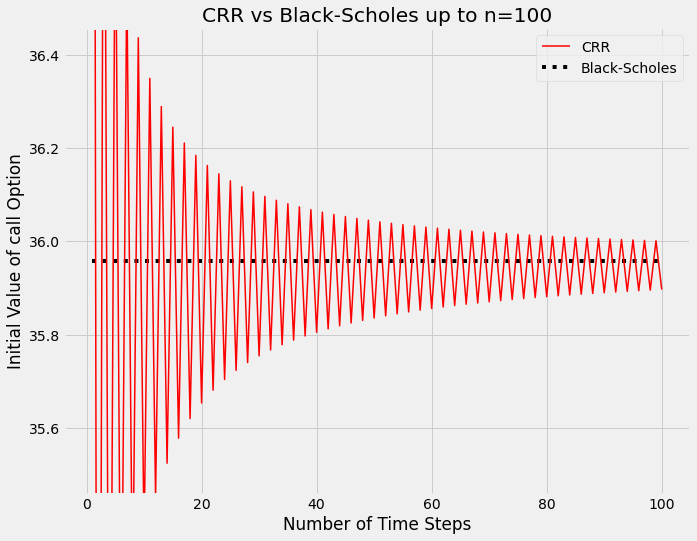

In [4]:
# Plot CRR Model for various number of time steps and compare it to BS value
arr=[]
for n in range(1, 101, 1):
    arr.append(BOPM_CRR(S,K,r,q,sigma,T,n,Option_Type))
index = np.linspace(1, 100, 100)
plt.figure(figsize=(10,8))
plt.hlines(BSC(S,K,r,q,sigma,T,0),xmin=1,xmax= 100,linestyle='dotted',colors='black',label = 'Black-Scholes')
plt.plot(index, arr ,lw = 1.5, label = 'CRR', color='red')
plt.title('CRR vs Black-Scholes up to n=100')
plt.xlabel('Number of Time Steps')
plt.ylabel(f'Initial Value of {Option_Type} Option')
plt.ylim(BSC(100,100,0.05,0,0.3,T,0)-0.5,BSC(100,100,0.05,0,0.3,T,0)+0.5)
plt.legend()
plt.show()

# Chance Model Risk-Neutral Probabilities

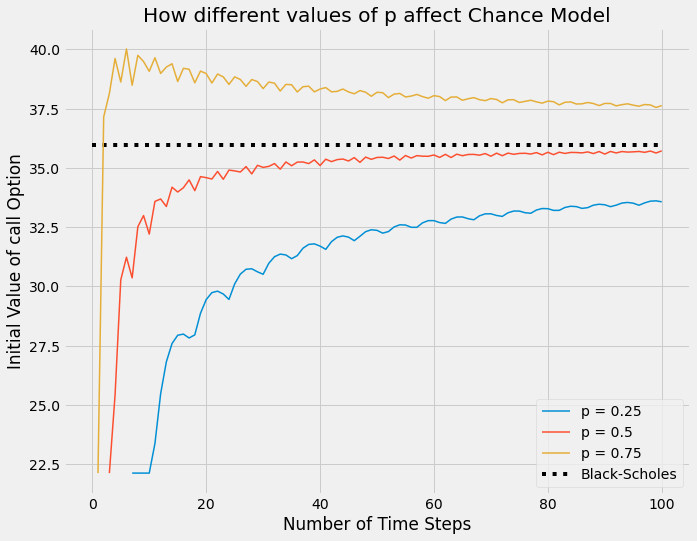

In [5]:
# Plot 3 different risk-neutral probabilities for Chance Model and compare it to BS Value
arr1=[]
arr2=[]
arr3=[]
for n in range(1, 101):
    arr1.append(BOPM_Chance(S,K,r,q,sigma,T,n,0.25,Option_Type))
    arr2.append(BOPM_Chance(S,K,r,q,sigma,T,n,0.5,Option_Type))
    arr3.append(BOPM_Chance(S,K,r,q,sigma,T,n,0.75,Option_Type))
index = np.linspace(1, 100, 100)
plt.figure(figsize=(10,8))
plt.hlines(BSC(S,K,r,q,sigma,T,0),xmin=0,xmax= 100,linestyle='dotted',colors='black',label = 'Black-Scholes')
plt.plot(index, arr1 ,lw = 1.5, label = 'p = 0.25')
plt.plot(index, arr2 ,lw = 1.5, label = 'p = 0.5')
plt.plot(index, arr3 ,lw = 1.5, label = 'p = 0.75')
plt.title('How different values of p affect Chance Model')
plt.xlabel('Number of Time Steps')
plt.ylabel(f'Initial Value of {Option_Type} Option')
plt.legend()
plt.show()

In [6]:
# Calculate average relative error to see which value of p is closest to BS value
bs = BSC(S,K,r,q,sigma,T,0)
are1 = 100*(abs(arr1[-1]-bs)/bs)
are2 = 100*(abs(arr2[-1]-bs)/bs)
are3 = 100*(abs(arr3[-1]-bs)/bs)

print(f'The Average Relative Error for p=0.25 is {are1:0.5f}%')
print(f'The Average Relative Error for p=0.50 is {are2:0.5f}%')
print(f'The Average Relative Error for p=0.75 is {are3:0.5f}%')

The Average Relative Error for p=0.25 is 6.64132%
The Average Relative Error for p=0.50 is 0.65786%
The Average Relative Error for p=0.75 is 4.65594%


In [7]:
# Let us see if this holds for large n
for i in np.linspace(0.45,0.55,11):
    temp = BOPM_Chance(S,K,r,q,sigma,T,1000000,i,Option_Type)
    are = 100*(abs(temp-bs)/bs)
    print(f'For p={i:0.2f}, the Average Relative Error is {are:0.5f}%')

For p=0.45, the Average Relative Error is 0.00968%
For p=0.46, the Average Relative Error is 0.00775%
For p=0.47, the Average Relative Error is 0.00582%
For p=0.48, the Average Relative Error is 0.00390%
For p=0.49, the Average Relative Error is 0.00200%
For p=0.50, the Average Relative Error is 0.00007%
For p=0.51, the Average Relative Error is 0.00183%
For p=0.52, the Average Relative Error is 0.00377%
For p=0.53, the Average Relative Error is 0.00569%
For p=0.54, the Average Relative Error is 0.00761%
For p=0.55, the Average Relative Error is 0.00955%


# CRR vs Chance

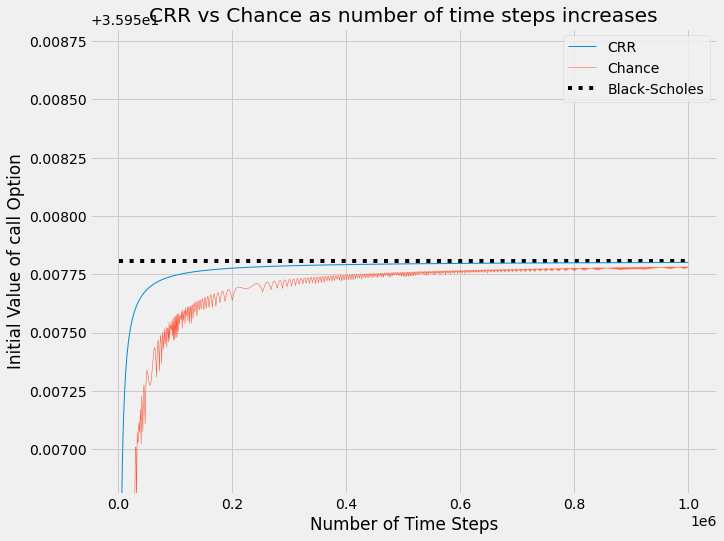

In [8]:
# Plot both models for up to a million time steps and see how both models converge to BS value
arr1=[]
arr2=[]
for n in np.linspace(1000, 1000000, 1000):
    arr1.append(BOPM_CRR(S,K,r,q,sigma,T,n,Option_Type))
    arr2.append(BOPM_Chance(S,K,r,q,sigma,T,n,0.5,Option_Type))
index = np.linspace(1000, 1000000, 1000)
plt.figure(figsize=(10,8))
plt.hlines(BSC(S,K,r,q,sigma,T,0),xmin=1000,xmax= 1000000,linestyle='dotted', colors='black',label = 'Black-Scholes')
plt.plot(index, arr1 ,lw = 1, label = 'CRR')
plt.plot(index, arr2 ,lw = 0.5, label = 'Chance')
plt.title('CRR vs Chance as number of time steps increases')
plt.xlabel('Number of Time Steps')
plt.ylabel(f'Initial Value of {Option_Type} Option')
plt.ylim(BSC(S,K,r,q,sigma,T,0)-0.001,BSC(S,K,r,q,sigma,T,0)+0.001)
plt.legend()
plt.show()

Note how although our CRR graph looks smooth, this is because we are only calculating time steps in intervals of 1000.

# CRR and Chance for extremely large n

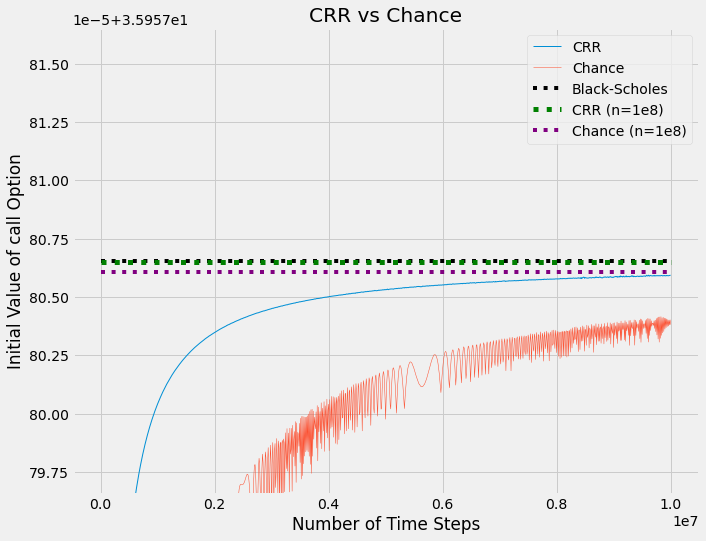

In [9]:
# See how the models fare at the high time steps only
arr1=[]
arr2=[]
for n in np.linspace(1e4, 1e7, 1000):
    arr1.append(BOPM_CRR(S,K,r,q,sigma,T,n,Option_Type))
    arr2.append(BOPM_Chance(S,K,r,q,sigma,T,n,0.5,Option_Type))
index = np.linspace(1e4, 1e7, 1000)
plt.figure(figsize=(10,8))
plt.hlines(BSC(S,K,r,q,sigma,T,0),xmin=1e4,xmax= 1e7,linestyle='dotted', colors='black',label = 'Black-Scholes')
plt.hlines(BOPM_CRR(S,K,r,q,sigma,T,1e8,Option_Type),xmin=1e4,xmax= 1e7,linestyle='dotted', lw=5, colors='green',label = 'CRR (n=1e8)')
plt.hlines(BOPM_Chance(S,K,r,q,sigma,T,1e8,0.5,Option_Type),xmin=1e4,xmax= 1e7,linestyle='dotted',colors='purple',label = 'Chance (n=1e8)')
plt.plot(index, arr1 ,lw = 1, label = 'CRR')
plt.plot(index, arr2 ,lw = 0.5, label = 'Chance')
plt.title('CRR vs Chance')
plt.xlabel('Number of Time Steps')
plt.ylabel(f'Initial Value of {Option_Type} Option')
plt.ylim(BSC(S,K,r,q,sigma,T,0)-1e-5,BSC(S,K,r,q,sigma,T,0)+1e-5)
plt.legend()
plt.show()

In [10]:
bs = BSC(S,K,r,q,sigma,T,0)
are1 = 100*(abs(arr1[-1]-bs)/bs)
are2 = 100*(abs(arr2[-1]-bs)/bs)
print(f'The Average Relative Error of the CRR Model for 10^7 time steps is {are1*1e6}e-6 %')
print(f'The Average Relative Error of the Chance Model for 10^7 time steps is {are2*1e6}e-6 %')

The Average Relative Error of the CRR Model for 10^7 time steps is 1.703506306727144e-6 %
The Average Relative Error of the Chance Model for 10^7 time steps is 7.581648466292229e-6 %


# Concluding remarks

We can clearly visually see how as the number of time steps increases, both of our models (CRR and Chance) converge to the Black-Scholes Model. Although this is simply just an observation and not a rigorous proof, please refer to the **"How BOPM converges to BS"** notebook for this.

Moreover, we have shown that the best risk-neutral probability to use in our Chance Model to choose our parameters $u$ and $d$ is $\bar{p} = 0.5$. Although Chance derived this model in 2007, when we substitute $\bar{p} = 0.5$ into his formulae, we find the same equations as those Chriss proposed in 1996. This is just one of many examples as to how, many models are connected to other models and how they all converge to the Black-Scholes Model as the number of time steps approach infinity.

Yet, due to the relative errors we calculated, for our particular set of parameters, we find that the CRR model is more accurate within 10^7 time steps and also converges slightly quicker than the Chance Model.